In [1]:
# Grundläggande bibliotek
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Train/validation-split
from sklearn.model_selection import train_test_split

#import sys
#!{sys.executable} -m pip install tensorflow

# TensorFlow / Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras import regularizers
from tensorflow.keras.callbacks import EarlyStopping

tf.keras.utils.set_random_seed(42)


In [2]:
(X_train_full, y_train_full), (X_test, y_test) = keras.datasets.fashion_mnist.load_data()

print("X_train_full shape:", X_train_full.shape)
print("y_train_full shape:", y_train_full.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train_full shape: (60000, 28, 28)
y_train_full shape: (60000,)
X_test shape: (10000, 28, 28)
y_test shape: (10000,)


In [3]:
print("Unika labels:", np.unique(y_train_full))

print("Minsta pixelvärde:", X_train_full.min())
print("Största pixelvärde:", X_train_full.max())

Unika labels: [0 1 2 3 4 5 6 7 8 9]
Minsta pixelvärde: 0
Största pixelvärde: 255


In [4]:
# Class names
class_names = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]

class_counts = pd.Series(y_train_full).value_counts().sort_index()

class_distribution = pd.DataFrame({
    "class_id": class_counts.index,
    "class_name": [class_names[i] for i in class_counts.index],
    "count": class_counts.values
})

class_distribution

,class_id,class_name,count
0,0,T-shirt/top,6000
1,1,Trouser,6000
2,2,Pullover,6000
3,3,Dress,6000
4,4,Coat,6000
5,5,Sandal,6000
6,6,Shirt,6000
7,7,Sneaker,6000
8,8,Bag,6000
9,9,Ankle boot,6000


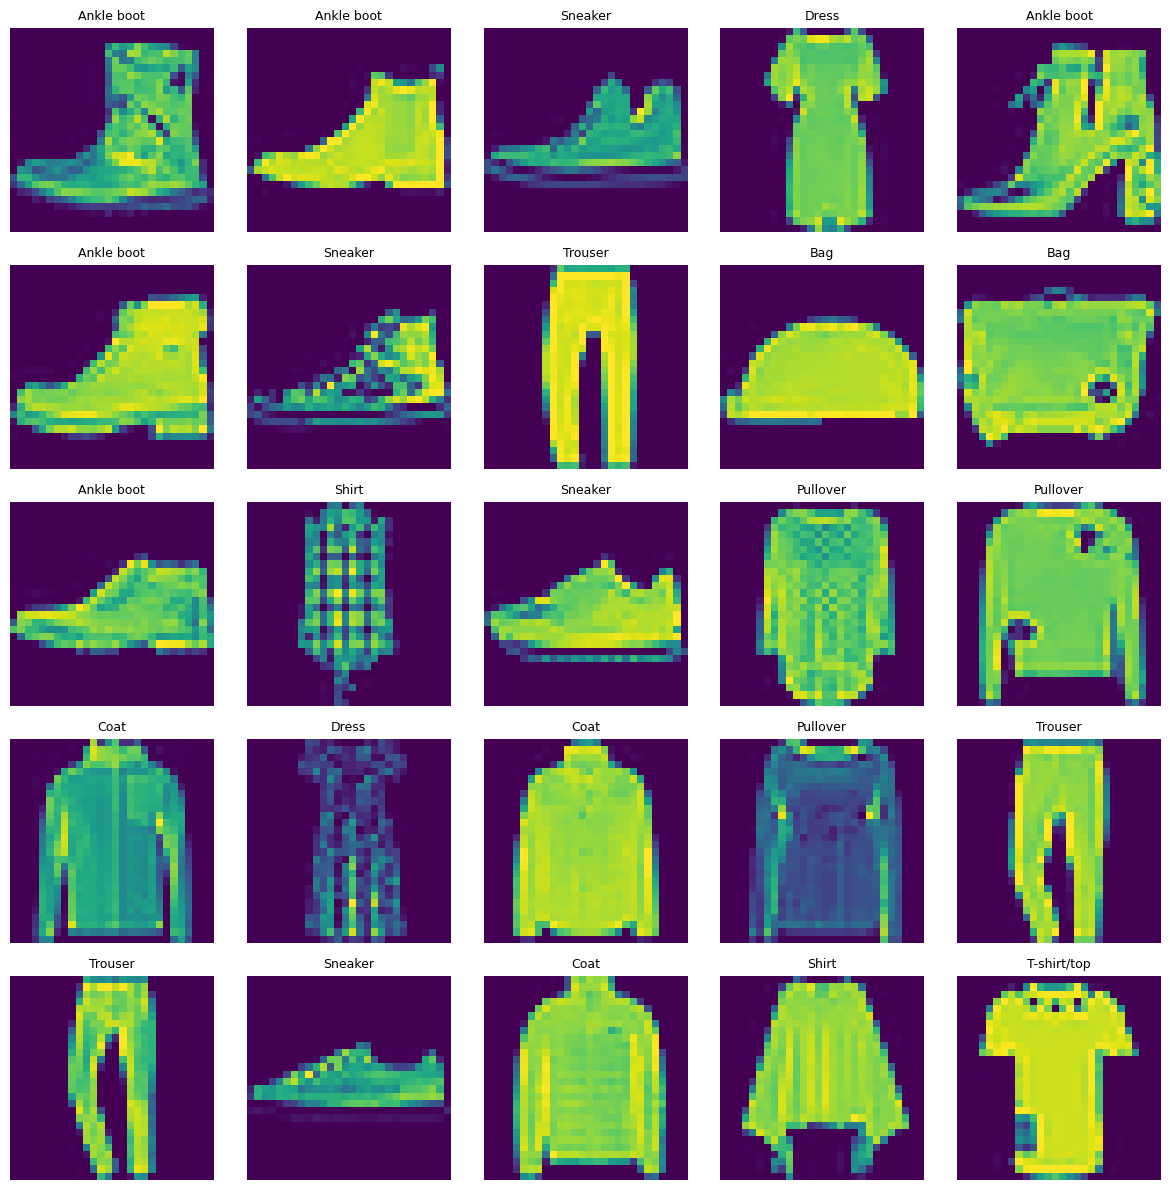

In [5]:
def  plot_image_grid(X, y, class_names, n_images=25, random_state=42):
    rng = np.random.default_rng(random_state)
    indices = rng.choice(len(X), size=n_images, replace=False)

    grid_size = int(np.ceil(np.sqrt(n_images)))

    plt.figure(figsize=(12, 12))
    
    for plot_index, image_index in enumerate(indices):
        plt.subplot(grid_size, grid_size, plot_index + 1)
        plt.imshow(X[image_index])
        plt.title(class_names[y[image_index]], fontsize=9)
        plt.axis("off")
    
    plt.tight_layout()
    plt.show()


plot_image_grid(
    X_train_full,
    y_train_full,
    class_names,
    n_images=25
)

## Dataförståelse

Datasetet innehåller totalt **70 000 bilder**, där `X_train_full` består av **60 000 träningsbilder** och `X_test` av **10 000 testbilder**. Varje bild har storleken **28 × 28 pixlar**, och tillhörande etiketter finns i `y_train_full` och `y_test`.

Datasetet innehåller 10 klasser:

- T-shirt/top
- Trouser
- Pullover
- Dress
- Coat
- Sandal
- Shirt
- Sneaker
- Bag
- Ankle boot

Varje klass innehåller **6000 bilder**, vilket innebär att datasetet är **balanserat** utan över- eller underrepresenterade klasser.

Baserat på de första 25 bilderna som visualiserades verkar även etiketteringen vara korrekt, då bilderna överensstämde med sina respektive klasser.

In [6]:
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.10,
    random_state=42,
    stratify=y_train_full
)

print("X_train", X_train.shape)
print("X_val", X_val.shape)
print("X_test", X_test.shape)

X_train (54000, 28, 28)
X_val (6000, 28, 28)
X_test (10000, 28, 28)


In [7]:
X_train = X_train.astype("float32") / 255.0
X_val = X_val.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0


print("Minsta värde efter normalisering:", X_train.min())
print("Största värde efter normalisering:", X_train.max())

X_train = X_train[..., np.newaxis]
X_val = X_val[..., np.newaxis]
X_test = X_test[..., np.newaxis]

print("X_train shape efter kanal-dimension:", X_train.shape)
print("X_val shape efter kanal-dimension:", X_val.shape)
print("X_test shape efter kanal-dimension:", X_test.shape)

Minsta värde efter normalisering: 0.0
Största värde efter normalisering: 1.0
X_train shape efter kanal-dimension: (54000, 28, 28, 1)
X_val shape efter kanal-dimension: (6000, 28, 28, 1)
X_test shape efter kanal-dimension: (10000, 28, 28, 1)


## Förberedelse av data


### Dela upp träningsdata i träning och validering
Vi delar upp `X_train_full` och `y_train_full` i:

- **Träningsdata (X_train, y_train)**
- **Valideringsdata (X_val, y_val)**

Vi använder:
- 10% av datan som valideringsset (`test_size=0.10`)
- `stratify=y_train_full` för att behålla samma klassfördelning i båda delarna
- `random_state=42` för att få samma uppdelning varje gång

### Normalisering av pixelvärden
Vi konverterar bilderna till `float32` och skalar pixelvärden från:

- **0–255 → 0–1**

Detta görs för:
- snabbare och stabilare träning
- bättre numerisk stabilitet i modellen

Vi verifierar även att:
- minsta värde ≈ 0
- största värde ≈ 1

### Lägga till kanal-dimension
Eftersom bilderna är gråskaliga lägger vi till en extra dimension:

- Från: `(28, 28)`
- Till: `(28, 28, 1)`

Detta krävs för att neurala nätverk (t.ex. CNN) ska kunna behandla bilderna korrekt.

In [8]:
model = keras.Sequential()

model.add(layers.Input(shape=(28, 28, 1)))
model.add(layers.Conv2D(32, (3, 3), padding="same", activation="relu"))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), padding="same", activation="relu"))
model.add(layers.MaxPooling2D(2, 2))
model.add(layers.Flatten())
model.add(layers.Dense(64, activation="relu"))
model.add(layers.Dense(10, activation="softmax"))

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       200,768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 220,234 (860.29 KB)

 Trainable params: 220,234 (860.29 KB)

 Non-trainable params: 0 (0.00 B)

### Modellskapande 
Vi bygger en sekventiell modell med följande lager:

- Conv2D (32 filter, 3×3) — extraherar lokala mönster (kanter, texturer)
- MaxPooling2D (2×2) — minskar dimensionerna och behåller viktigaste informationen
- Conv2D (64 filter, 3×3) — extraherar mer komplexa mönster
- MaxPooling2D (2×2) — ytterligare dimensionsreduktion
- Flatten — gör om 2D-features till en 1D-vektor
- Dense (64 neuroner, ReLU) — lär sig kombinationer av features
- Dense (10 neuroner, softmax) — ger sannolikheter för varje klass (0–9)

Vi använder padding="same" för att behålla bildens dimensioner genom konvolutionslagren.

In [9]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
)

### Kompilering
Modellen kompileras med:

- Optimizer: Adam(learning_rate=0.001) -- adaptiv inlärning
- Loss: SparseCategoricalCrossentropy -- lämplig för flerklass-klassificering
- Metric: Accuracy -- andel korrekta klassificeringar

In [10]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=5,
    batch_size=64
)

Epoch 1/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8349 - loss: 0.4604 - val_accuracy: 0.8712 - val_loss: 0.3573
Epoch 2/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8923 - loss: 0.3011 - val_accuracy: 0.8910 - val_loss: 0.3042
Epoch 3/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9085 - loss: 0.2561 - val_accuracy: 0.8942 - val_loss: 0.2951
Epoch 4/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9186 - loss: 0.2255 - val_accuracy: 0.8973 - val_loss: 0.2832
Epoch 5/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9269 - loss: 0.2012 - val_accuracy: 0.9017 - val_loss: 0.2750


### Träning
Modellen tränas med:

- 5 epoker -- varje epok går igenom hela träningsdatan en gång
- Batch size 64 -- uppdaterar vikterna efter varje batch
- Valideringsdata -- utvärderar modellen på osedd data efter varje epok

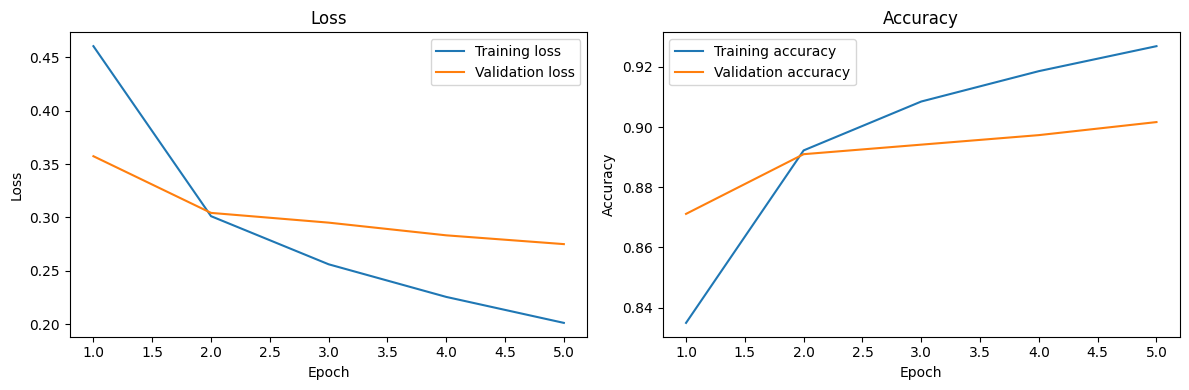

In [11]:
def plot_history(history):
    history_df = pd.DataFrame(history.history)

    epochs = range(1, len(history_df) +1)

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, history_df["loss"], label="Training loss")
    plt.plot(epochs, history_df["val_loss"], label="Validation loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Loss")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, history_df["accuracy"], label="Training accuracy")
    plt.plot(epochs, history_df["val_accuracy"], label="Validation accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Accuracy")
    plt.legend()

    plt.tight_layout()
    plt.show()

plot_history(history)

### Visualisering av träningshistorik
Vi plottar:

- Loss (träning vs validering) -- visar om modellen överanpassar
- Accuracy (träning vs validering) -- visar hur väl modellen generaliserar

### Test och förbättring av modellen

- Vi tränar först en baseline-modell och testar sedan olika förändringar för att se om resultatet förbättras.

- Vi testar fler neuroner, fler filter och ändrad learning rate.


In [12]:
model_baseline = keras.Sequential([
    layers.Input(shape=(28, 28, 1)),

    layers.Conv2D(32, (3, 3), padding="same", activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), padding="same", activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dense(10, activation="softmax")
])

model_baseline.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history_baseline = model_baseline.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=64,
    validation_data=(X_val, y_val)
)

Epoch 1/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8280 - loss: 0.4757 - val_accuracy: 0.8592 - val_loss: 0.3757
Epoch 2/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8878 - loss: 0.3151 - val_accuracy: 0.8915 - val_loss: 0.3035
Epoch 3/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9033 - loss: 0.2674 - val_accuracy: 0.9003 - val_loss: 0.2814
Epoch 4/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9143 - loss: 0.2342 - val_accuracy: 0.9043 - val_loss: 0.2701
Epoch 5/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9241 - loss: 0.2073 - val_accuracy: 0.9073 - val_loss: 0.2559
Epoch 6/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9334 - loss: 0.1842 - val_accuracy: 0.9123 - val_loss: 0.2433
Epoch 7/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9418 - loss: 0.1636 - val_accuracy: 0.9135 - val_loss: 0.2535
Epoch 8/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9487 - loss: 0.1439 - val_accuracy: 0.

### Baseline-modell

Först tränas en baseline-modell för att få ett resultat att jämföra med.

In [13]:
baseline_test_loss, baseline_test_accuracy = model_baseline.evaluate(X_test, y_test)

print("Baseline test loss:", baseline_test_loss)
print("Baseline test accuracy:", baseline_test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8952 - loss: 0.3559  
Baseline test loss: 0.3559114634990692
Baseline test accuracy: 0.8952000141143799


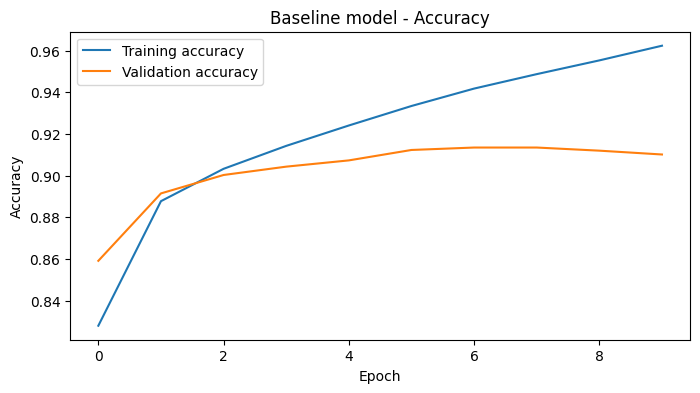

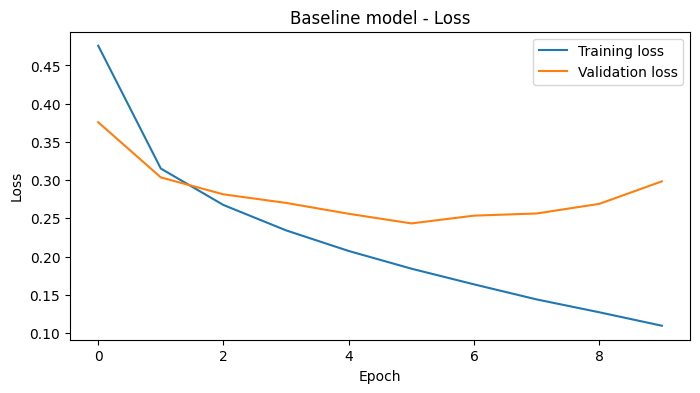

In [14]:
def plot_history(history, title):
    plt.figure(figsize=(8, 4))
    plt.plot(history.history["accuracy"], label="Training accuracy")
    plt.plot(history.history["val_accuracy"], label="Validation accuracy")
    plt.title(title + " - Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.show()

    plt.figure(figsize=(8, 4))
    plt.plot(history.history["loss"], label="Training loss")
    plt.plot(history.history["val_loss"], label="Validation loss")
    plt.title(title + " - Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()

plot_history(history_baseline, "Baseline model")

### Testar med fler neuroner

ökar antalet neuroner i Dense-lagret från 64 till 128.

Epoch 1/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8398 - loss: 0.4429 - val_accuracy: 0.8772 - val_loss: 0.3301
Epoch 2/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8952 - loss: 0.2894 - val_accuracy: 0.9002 - val_loss: 0.2787
Epoch 3/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9118 - loss: 0.2427 - val_accuracy: 0.9070 - val_loss: 0.2564
Epoch 4/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9236 - loss: 0.2096 - val_accuracy: 0.9108 - val_loss: 0.2477
Epoch 5/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9333 - loss: 0.1824 - val_accuracy: 0.9142 - val_loss: 0.2398
Epoch 6/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9429 - loss: 0.1573 - val_accuracy: 0.9173 - val_loss: 0.2289
Epoch 7/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9510 - loss: 0.1342 - val_accuracy: 0.9185 - val_loss: 0.2305
Epoch 8/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9599 - loss: 0.1129 - val_accuracy: 0.

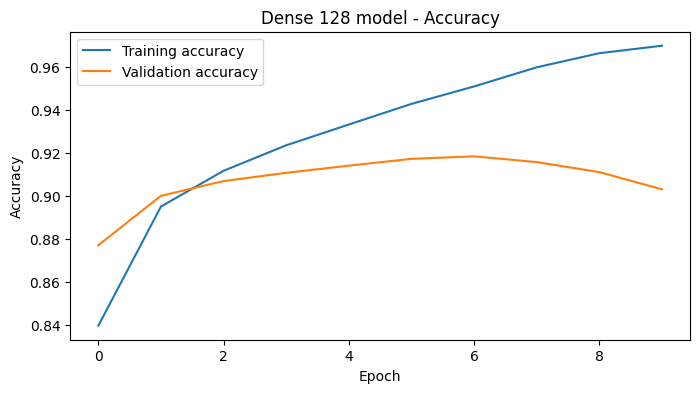

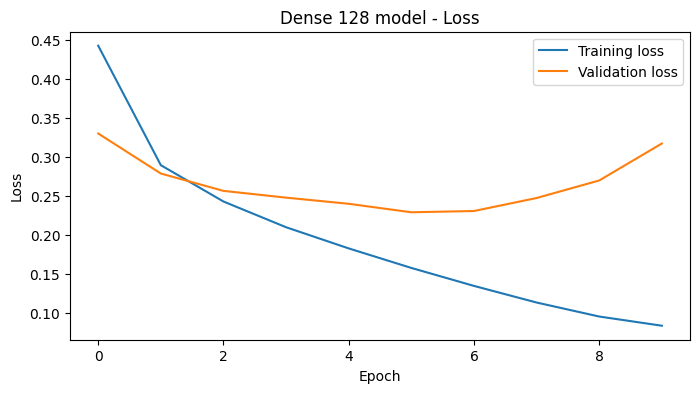

In [15]:
model_dense_128 = keras.Sequential([
    layers.Input(shape=(28, 28, 1)),

    layers.Conv2D(32, (3, 3), padding="same", activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), padding="same", activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dense(10, activation="softmax")
])

model_dense_128.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history_dense_128 = model_dense_128.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=64,
    validation_data=(X_val, y_val)
)

dense_128_test_loss, dense_128_test_accuracy = model_dense_128.evaluate(X_test, y_test)

print("Dense 128 test loss:", dense_128_test_loss)
print("Dense 128 test accuracy:", dense_128_test_accuracy)

plot_history(history_dense_128, "Dense 128 model")

### Testar med fler filter

testar med fler filter i Conv2D-lagren.

Epoch 1/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.8446 - loss: 0.4329 - val_accuracy: 0.8687 - val_loss: 0.3502
Epoch 2/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8989 - loss: 0.2782 - val_accuracy: 0.8870 - val_loss: 0.3062
Epoch 3/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9159 - loss: 0.2305 - val_accuracy: 0.9032 - val_loss: 0.2733
Epoch 4/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9284 - loss: 0.1955 - val_accuracy: 0.9077 - val_loss: 0.2603
Epoch 5/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9406 - loss: 0.1662 - val_accuracy: 0.9102 - val_loss: 0.2682
Epoch 6/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9496 - loss: 0.1408 - val_accuracy: 0.9118 - val_loss: 0.2666
Epoch 7/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9580 - loss: 0.1173 - val_accuracy: 0.9185 - val_loss: 0.2470
Epoch 8/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9653 - loss: 0.0999 - val_accuracy: 0.

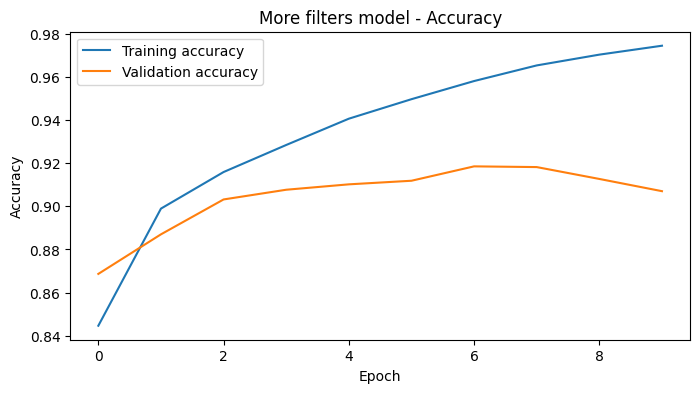

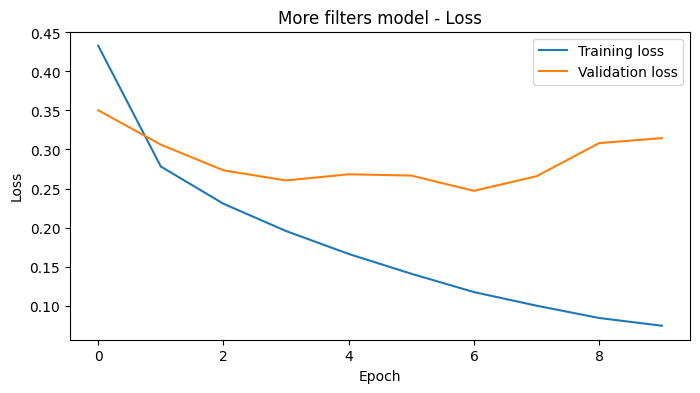

In [16]:
model_more_filters = keras.Sequential([
    layers.Input(shape=(28, 28, 1)),

    layers.Conv2D(64, (3, 3), padding="same", activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), padding="same", activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dense(10, activation="softmax")
])

model_more_filters.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history_more_filters = model_more_filters.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=64,
    validation_data=(X_val, y_val)
)

more_filters_test_loss, more_filters_test_accuracy = model_more_filters.evaluate(X_test, y_test)

print("More filters test loss:", more_filters_test_loss)
print("More filters test accuracy:", more_filters_test_accuracy)

plot_history(history_more_filters, "More filters model")

### Testar med lägre learning rate

testar med en lägre learning rate.

Epoch 1/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8098 - loss: 0.5336 - val_accuracy: 0.8562 - val_loss: 0.3860
Epoch 2/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8777 - loss: 0.3427 - val_accuracy: 0.8855 - val_loss: 0.3189
Epoch 3/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8942 - loss: 0.2968 - val_accuracy: 0.8980 - val_loss: 0.2835
Epoch 4/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9036 - loss: 0.2675 - val_accuracy: 0.9053 - val_loss: 0.2622
Epoch 5/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9111 - loss: 0.2447 - val_accuracy: 0.9120 - val_loss: 0.2457
Epoch 6/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9174 - loss: 0.2258 - val_accuracy: 0.9102 - val_loss: 0.2405
Epoch 7/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9238 - loss: 0.2088 - val_accuracy: 0.9145 - val_loss: 0.2331
Epoch 8/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9297 - loss: 0.1938 - val_accuracy: 0.

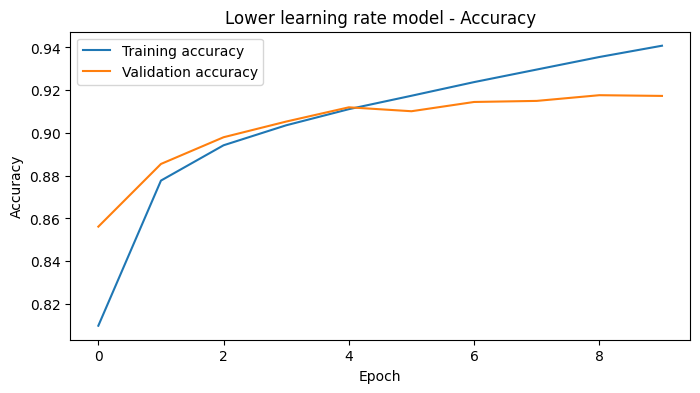

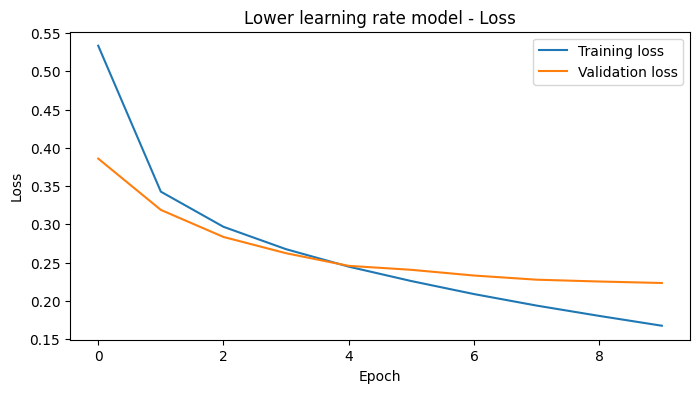

In [17]:
model_lower_lr = keras.Sequential([
    layers.Input(shape=(28, 28, 1)),

    layers.Conv2D(32, (3, 3), padding="same", activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), padding="same", activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dense(10, activation="softmax")
])

optimizer = keras.optimizers.Adam(learning_rate=0.0005)

model_lower_lr.compile(
    optimizer=optimizer,
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history_lower_lr = model_lower_lr.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=64,
    validation_data=(X_val, y_val)
)

lower_lr_test_loss, lower_lr_test_accuracy = model_lower_lr.evaluate(X_test, y_test)

print("Lower learning rate test loss:", lower_lr_test_loss)
print("Lower learning rate test accuracy:", lower_lr_test_accuracy)

plot_history(history_lower_lr, "Lower learning rate model")

### Jämförelse av modellerna

jämför modellerna med test accuracy och test loss.

In [18]:
results = pd.DataFrame({
    "Model": [
        "Baseline",
        "Dense 128",
        "More filters",
        "Lower learning rate"
    ],
    "Test loss": [
        baseline_test_loss,
        dense_128_test_loss,
        more_filters_test_loss,
        lower_lr_test_loss
    ],
    "Test accuracy": [
        baseline_test_accuracy,
        dense_128_test_accuracy,
        more_filters_test_accuracy,
        lower_lr_test_accuracy
    ]
})

results

,Model,Test loss,Test accuracy
0,Baseline,0.355911,0.8952
1,Dense 128,0.357910,0.8980
2,More filters,0.361629,0.9009
3,Lower learning rate,0.261193,0.9076


### Analys

Förändringar i modellen påverkade resultatet på olika sätt.

Lower learning rate gav högst test accuracy bland de första modellförändringar och hade även lägst test loss.

More filters och Dense128 förbättrade baseline, men gav inte lika starka resultat som modellen med lägre learning rate.

## Fördjupning: Regularisering

Efter att vi testat olika modellförändringar såg vi att mer komplexa modeller kunde ge högre training accuracy, men inte alltid bättre generalisering. Därför testar vi regularisering.

Syftet med regularisering är att minska risken för overfitting, alltså att modellen lär sig träningsdatan för bra men presterar sämre på ny/osedd data.

Vi testar tre metoder:
- Dropout
- Early stopping
- L2-regularisering

## Dropout

Dropout innebär att modellen slumpmässigt stänger av en viss andel neuroner under träningen. Detta gör att modellen inte kan förlita sig för mycket på enskilda neuroner och kan därför minska overfitting.

Vi testar dropout med 0.3 efter Dense-lagret.

Epoch 1/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7781 - loss: 0.6266 - val_accuracy: 0.8658 - val_loss: 0.3811
Epoch 2/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8612 - loss: 0.3976 - val_accuracy: 0.8878 - val_loss: 0.3089
Epoch 3/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8772 - loss: 0.3458 - val_accuracy: 0.8983 - val_loss: 0.2779
Epoch 4/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8882 - loss: 0.3135 - val_accuracy: 0.9063 - val_loss: 0.2541
Epoch 5/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8984 - loss: 0.2882 - val_accuracy: 0.9072 - val_loss: 0.2475
Epoch 6/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9032 - loss: 0.2681 - val_accuracy: 0.9163 - val_loss: 0.2314
Epoch 7/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9087 - loss: 0.2531 - val_accuracy: 0.9173 - val_loss: 0.2236
Epoch 8/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9133 - loss: 0.2407 - val_accuracy: 0.

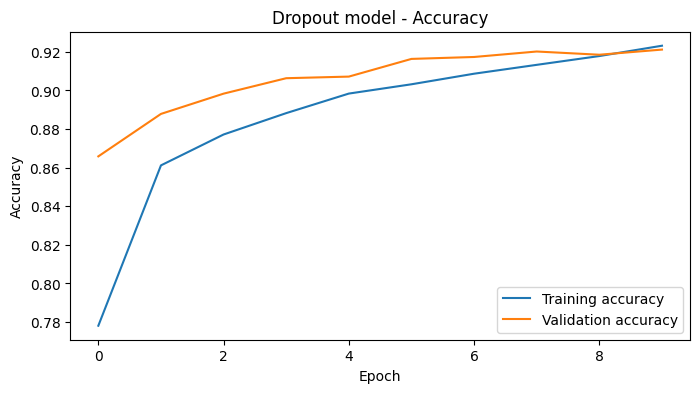

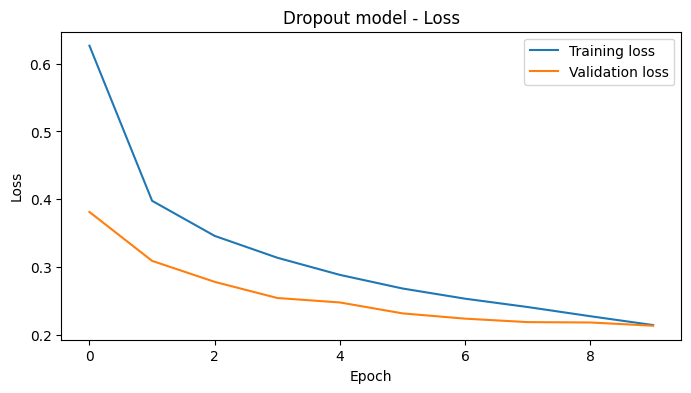

In [19]:
# Model with dropout
# Samma grundstruktur som tidigare modeller, men med en Dropout-lager efter Dense-lagret.
model_dropout = keras.Sequential([
    layers.Input(shape=(28, 28, 1)),

    layers.Conv2D(32, (3, 3), padding="same", activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), padding="same", activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(10, activation="softmax")
])

# Vi använder samma learning rate som modellen med lägre learning rate, eftersom Dropout kan göra att modellen lär sig långsammare och därmed kan gynnas av en lägre learning rate.
model_dropout.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0005),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# Vi tränar modellen och använder valideringsdata för att följa generalisering, med samma antal epoch och batch size som tidigare modeller för att göra resultaten mer jämförbara.
history_dropout = model_dropout.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=64,
    validation_data=(X_val, y_val)
)
# Vi utvärderar modellen på testdata för att se hur väl den generaliserar till helt nya data.
dropout_test_loss, dropout_test_accuracy = model_dropout.evaluate(X_test, y_test)

print("Dropout test loss:", dropout_test_loss)
print("Dropout test accuracy:", dropout_test_accuracy)

# Plottar tränings och valideringskurvor
plot_history(history_dropout, "Dropout model")

### Tolkning av Dropout resultat

Dropout gav en test accuracy på ca **0.9102** och test loss på ca **0.2479**.

Jämfört med baseline och flera av de mer komplexa modellerna blev resultatet stabilt. Training accuracy blev något lägre än i modellerna utan regularisering, vilket är ett förväntat resultat eftersom dropout gör träningen svårare.

Samtidigt blev validation accuracy hög och validation loss höll sig relativt stabil. Det tyder på att modellen generaliserade bättre och inte förlitade sig lika mycket på enskilda neuroner.

### Early stopping

Early stopping stoppar träningen när modellen inte längre förbättras på valideringsdatan. Detta är användbart eftersom modellen annars kan fortsätta förbättras på träningsdatan men börja prestera sämre på ny data.

Vi använder "val_loss" som mått och låter modellen stoppa om den inte förbättras på 3 epoker.

Epoch 1/30
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8100 - loss: 0.5328 - val_accuracy: 0.8600 - val_loss: 0.3913
Epoch 2/30
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8750 - loss: 0.3467 - val_accuracy: 0.8815 - val_loss: 0.3343
Epoch 3/30
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8917 - loss: 0.3035 - val_accuracy: 0.8917 - val_loss: 0.2964
Epoch 4/30
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9010 - loss: 0.2750 - val_accuracy: 0.9020 - val_loss: 0.2738
Epoch 5/30
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9089 - loss: 0.2522 - val_accuracy: 0.9115 - val_loss: 0.2498
Epoch 6/30
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9151 - loss: 0.2327 - val_accuracy: 0.9153 - val_loss: 0.2389
Epoch 7/30
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9224 - loss: 0.2155 - val_accuracy: 0.9192 - val_loss: 0.2307
Epoch 8/30
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9283 - loss: 0.1999 - val_accuracy: 0.

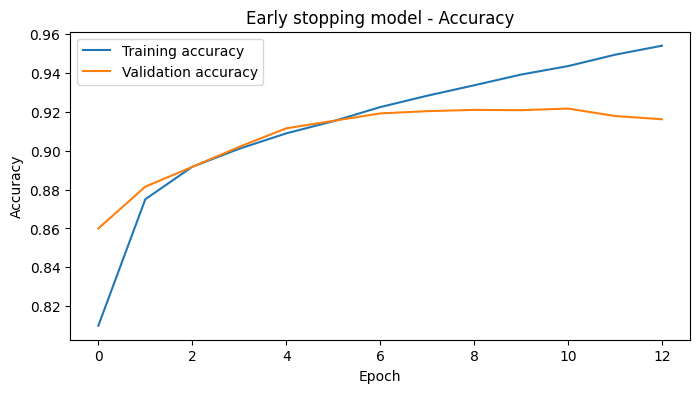

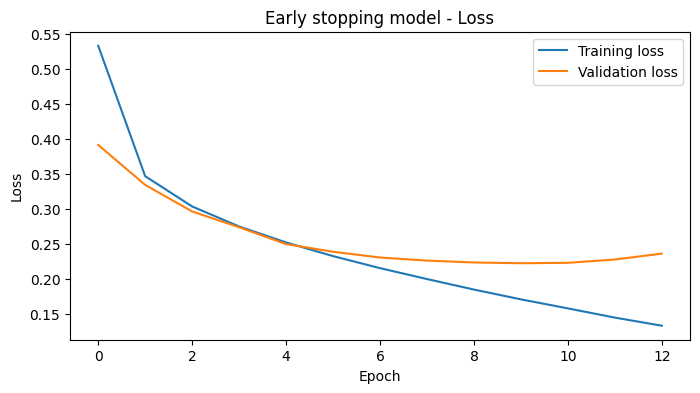

In [20]:
# Modell med early stopping
# Samma grundstruktur som tidigare modeller, skillnaden är att träningen kommer att avbrytas tidigt om valideringsförlusten inte förbättras under ett antal epoch, vilket kan hjälpa till att förhindra överanpassning.
model_early_stop = keras.Sequential([
    layers.Input(shape=(28, 28, 1)),

    layers.Conv2D(32, (3, 3), padding="same", activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), padding="same", activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dense(10, activation="softmax")
])
# Samma learning rate som tidigare modeller, eftersom early stopping inte direkt påverkar hur snabbt modellen lär sig, utan snarare när träningen avbryts baserat på valideringsförlusten.
model_early_stop.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0005),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)
# Early stopping övervakar val_loss och avbryter träningen om den inte förbättras under 3 epoch, samtidigt som den återställer de bästa vikterna som uppnåddes under träningen.
# restore_best_weights=True gör att modellen återställer de vikter som gav den bästa val_loss, vilket kan hjälpa till att få bättre prestanda på testdata även om träningen avbryts tidigt.
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)
# Vi sätter 30 epochs, men early stopping kommer sannolikt att avbryta träningen tidigare om modellen inte förbättras.
history_early_stop = model_early_stop.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=64,
    validation_data=(X_val, y_val),
    callbacks=[early_stop]
)
# Vi utvärderar modellen på testdata för att se hur väl den generaliserar till helt nya data, och för att se vilken effekt early stopping hade på prestanda.
early_stop_test_loss, early_stop_test_accuracy = model_early_stop.evaluate(X_test, y_test)

print("Early stopping test loss:", early_stop_test_loss)
print("Early stopping test accuracy:", early_stop_test_accuracy)
print("Stopped after epoch:", len(history_early_stop.history["loss"]))
# Plottar tränings och valideringskurvor
plot_history(history_early_stop, "Early stopping model")

### Tolkning av Early Stopping reslutat

Early stopping stoppade träningen efter **13 epoker**.

Test accuracy blev ca **0.9109** och test loss ca **0.2519**.

Resultatet visar att modellen inte behövde träna alla 30 epoker. När validation loss slutade förbättras stoppades träningen automatiskt och modellen återgick till de bästa vikterna.

Detta minskar risken för overfitting, eftersom modellen inte fortsätter träna långt efter att valideringsresultatet slutat förbättras.

### L2-regularisering

L2-regularisering straffar modellen om vikterna blir för stora. Det gör modellen mindre komplex och kan minska risken att den anpassar sig för mycket till träningsdatan.

Vi testar L2 på Dense-lagret.

Epoch 1/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8053 - loss: 0.6210 - val_accuracy: 0.8532 - val_loss: 0.4712
Epoch 2/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8699 - loss: 0.4311 - val_accuracy: 0.8635 - val_loss: 0.4270
Epoch 3/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8844 - loss: 0.3811 - val_accuracy: 0.8758 - val_loss: 0.3873
Epoch 4/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8939 - loss: 0.3481 - val_accuracy: 0.8823 - val_loss: 0.3661
Epoch 5/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9002 - loss: 0.3253 - val_accuracy: 0.8885 - val_loss: 0.3490
Epoch 6/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9055 - loss: 0.3084 - val_accuracy: 0.8875 - val_loss: 0.3484
Epoch 7/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9108 - loss: 0.2937 - val_accuracy: 0.8887 - val_loss: 0.3475
Epoch 8/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9144 - loss: 0.2826 - val_accuracy: 0.

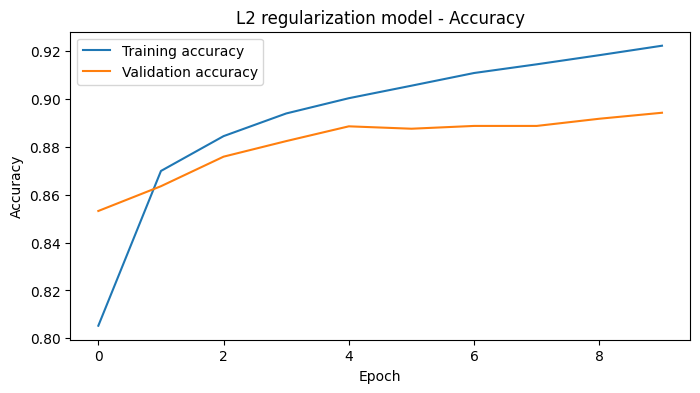

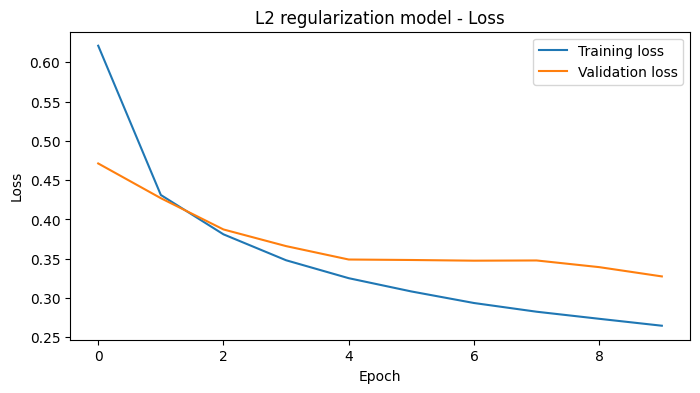

In [21]:
# Modell med L2-regularisering
# L2 läggs på Dense-lagret för att straffa stora vikter, vilket kan hjälpa till att förhindra överanpassning genom att hålla vikterna små.
model_l2 = keras.Sequential([
    layers.Input(shape=(28, 28, 1)),

    layers.Conv2D(32, (3, 3), padding="same", activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), padding="same", activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(64, activation="relu", kernel_regularizer=regularizers.l2(0.001)),
    layers.Dense(10, activation="softmax")
])
# Samma learning rate som i överiga modeller, eftersom L2-regularisering inte direkt påverkar hur snabbt modellen lär sig, utan snarare straffar stora vikter under träningen.
model_l2.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0005),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)
# Vi tränar modellen och använder samma antal epoch och batch size som tidigare modeller för att göra resultaten mer jämförbara.
history_l2 = model_l2.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=64,
    validation_data=(X_val, y_val)
)
# Vi utvärderar modellen på testdata för att se hur väl den generaliserar till helt nya data.
l2_test_loss, l2_test_accuracy = model_l2.evaluate(X_test, y_test)

print("L2 regularization test loss:", l2_test_loss)
print("L2 regularization test accuracy:", l2_test_accuracy)
# Plottar tränings och valideringskurvor
plot_history(history_l2, "L2 regularization model")

### Tolking av L2 resultat

L2-regularisering gav en test accuracy på ca **0.8811** och test loss på ca **0.3655**.

Training accuracy ökade långsammare än i modellerna utan regularisering, vilket är förväntat eftersom L2 begränsar modellens vikter.

I vårt fall gav L2 lägre test accuracy än både Dropout och Early Stopping. Det kan tyda på att L2-styrkan var något för hård eller att just denna modell inte hade lika stor nytta av L2 som av Dropout eller Early Stopping.

L2 är ändå relevant eftersom den visar hur man kan minska modellens komplexitet genom att då straffa stora vikter.

## Extra experiment: olika Dropout-nivåer

För att fördjupa oss lite mer testar vi flera nivåer av Dropout. Syftet är att se hur styrkan på regulariseringen påverkar modellens resultat och generalisering.

Vi testar:
- Dropout 0.1
- Dropout 0.3
- Dropout 0.5

En låg dropout kan ge för svag regularisering, medan en för hög dropout kan göra att modellen får svårt att lära sig tillräckligt mycket.

In [22]:
# Funktion som bygger en modell med valfri dropout rate

def build_dropout_model(dropout_rate):
    model = keras.Sequential([
        layers.Input(shape=(28, 28, 1)),

        layers.Conv2D(32, (3, 3), padding="same", activation="relu"),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(64, (3, 3), padding="same", activation="relu"),
        layers.MaxPooling2D((2, 2)),

        layers.Flatten(),
        layers.Dense(64, activation="relu"),
        layers.Dropout(dropout_rate),
        layers.Dense(10, activation="softmax")
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.0005),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

#Lista för att spara resultaten av olika dropout rates
dropout_experiments = []

# Testar flera dropout rates
for rate in [0.1, 0.3, 0.5]:
    print(f"Training model with dropout rate: {rate}")
    model_temp = build_dropout_model(rate)
    history_temp = model_temp.fit(
        X_train,
        y_train,
        epochs=10,
        batch_size=64,
        validation_data=(X_val, y_val)
    )
    # Utvärderar modellen på testdata och sparar resultaten i listan
    test_loss, test_accuracy = model_temp.evaluate(X_test, y_test)
    dropout_experiments.append({
        "Dropout rate": rate,
        "Test loss": test_loss,
        "Test accuracy": test_accuracy,
        "Final train accuracy": history_temp.history["accuracy"][-1],
        "Final val accuracy": history_temp.history["val_accuracy"][-1],
        "Final train loss": history_temp.history["loss"][-1],
        "Final val loss": history_temp.history["val_loss"][-1]
    })
# Skapar en DataFrame för att jämföra resultaten av olika dropout rates
dropout_experiments_df = pd.DataFrame(dropout_experiments)
dropout_experiments_df.sort_values("Test accuracy", ascending=False)

Training model with dropout rate: 0.1
Epoch 1/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8036 - loss: 0.5487 - val_accuracy: 0.8762 - val_loss: 0.3557
Epoch 2/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8747 - loss: 0.3523 - val_accuracy: 0.8902 - val_loss: 0.3021
Epoch 3/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8892 - loss: 0.3062 - val_accuracy: 0.9060 - val_loss: 0.2681
Epoch 4/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8995 - loss: 0.2768 - val_accuracy: 0.9080 - val_loss: 0.2532
Epoch 5/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9079 - loss: 0.2542 - val_accuracy: 0.9145 - val_loss: 0.2322
Epoch 6/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9146 - loss: 0.2340 - val_accuracy: 0.9175 - val_loss: 0.2312
Epoch 7/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9214 - loss: 0.2160 - val_accuracy: 0.9227 - val_loss: 0.2126
Epoch 8/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.

,Dropout rate,Test loss,Test accuracy,Final train accuracy,Final val accuracy,Final train loss,Final val loss
0,0.1,0.241057,0.9160,0.936315,0.927333,0.173482,0.200782
1,0.3,0.246398,0.9122,0.916093,0.922000,0.227872,0.215200
2,0.5,0.253600,0.9087,0.899185,0.918000,0.278820,0.217442


### Tolkning av olika Dropout-nivåer

Vi testade flera nivåer av dropout för att undersöka hur styrkan på regulariseringen påverkar modellens prestanda.

Resultaten visade att Dropout 0.1 gav högst test accuracy (0.9160) och lägst test loss (0.2411).

När Dropout ökades till 0.3 och 0.5 sjönk test accuracy, medan test loss ökade.

Det tyder på att för stark regularisering kan göra att modellen får svårare att lära sig viktiga mönster från träningsdatan med högre Dropout vikter.

Samtidigt är syftet med Dropout inte bara att maximera training accuracy utan att förbättra generalisering och minska risken för overfitting.

I vårt fall verkar en lägre Dropout-nivå fungera bäst för just denna modell och datamängd.

Det viktigaste att ta från detta experiment är att regularisering behöver balanseras. För lite regularisering kan ge overfitting medan för mycket regularisering kan göra modellen svagare.

## Slutlig jämförelse

Här jämför vi baseline, tidigare modellförändringar och regulariseringsmetoderna.

In [23]:
# Skapar en tabell som sammanfattar resultaten från alla experiment, inklusive baseline, de olika modellerna vi testat & resultaten från dropout-experimentet.
final_results = pd.DataFrame({
    "Model": [
        "Baseline",
        "Dense 128",
        "More filters",
        "Lower learning rate",
        "Dropout (original)",
        "Early stopping",
        "L2 regularization"
    ],
    "Test loss": [
        baseline_test_loss,
        dense_128_test_loss,
        more_filters_test_loss,
        lower_lr_test_loss,
        dropout_test_loss,
        early_stop_test_loss,
        l2_test_loss
    ],
    "Test accuracy": [
        baseline_test_accuracy,
        dense_128_test_accuracy,
        more_filters_test_accuracy,
        lower_lr_test_accuracy,
        dropout_test_accuracy,
        early_stop_test_accuracy,
        l2_test_accuracy
    ]
})

# Omstrukturera dropout-resultaten för att passa in i tabellen
dropout_results_for_table = dropout_experiments_df.rename(columns={
    "Dropout rate": "Model",
    "Test loss": "Test loss",
    "Test accuracy": "Test accuracy"
})[["Model", "Test loss", "Test accuracy"]]

dropout_results_for_table["Model"] = dropout_results_for_table["Model"].apply(
    lambda x: f"Dropout {x}"
)

# Lägg till resultaten från extra dropout-experimentet i tabellen
final_results = pd.concat(
    [final_results, dropout_results_for_table],
    ignore_index=True
)
# Kombinera alla resultat i en tabell och sortera efter test accuracy för att se vilka modeller som presterade bäst.
final_results.sort_values("Test accuracy", ascending=False)

,Model,Test loss,Test accuracy
7,Dropout 0.1,0.241057,0.9160
8,Dropout 0.3,0.246398,0.9122
5,Early stopping,0.251867,0.9109
4,Dropout (original),0.247945,0.9102
9,Dropout 0.5,0.253600,0.9087
3,Lower learning rate,0.261193,0.9076
2,More filters,0.361629,0.9009
1,Dense 128,0.357910,0.8980
0,Baseline,0.355911,0.8952
6,L2 regularization,0.365468,0.8811


### Tolkning av slutlig jämförelse

Den slutliga jämförelsen visar att flera förändringar i modellen påverkar resultatet på olika sätt.

Den högsta test accuracy uppnåddes av Dropout 0.1 (0.9160), följt av Dropout 0.3 (0.9122) och Early Stopping med (0.9109). Detta visar tydligt att regularisering kan förbättra modellens generalisering.

Experimentet med olika dropout-nivåer visade också att starkare regularisering inte automatiskt ger bättre resultat. Detta då Dropout 0.1 presterade bättre än både Dropout 0.3, 0.5 och originella Dropout.

Lower learning rate gav också ett stabilt resultat (0.9076), vilket tyder på att en långsammare inlärning hjälpte modellen att lära sig mer stabilt.

Early stopping gav ett startk resultat med (0.9109) test accuracy.

L2-regularisering gav lägst resultat av alla modeller i vårt test (0.8811), vilket visar tecken på att denna metod inte passade lika bra för vår modell och våra parametrar.

Resultaten visar att regularisering behöver anpassas efter modellen. För stark regularisering förbättrar inte alltid generalisering och olika metoder kan påverka modellen på olika sätt.

## Slutsats

I det här projektet testade vi flertalet förändringar av vår CNN-modell för att undersöka hur olika val påverkar modellens prestanda. Vi jämförde en baseline-modell med förändringar som flera Dense-neuroner, fler filter, lägre learning rate och ett antal regulariseringsmetoder.

Resultaten visade att lower learning rate gav högst test accuracy bland modellförändringarna utan regularisering, medan Dense 128 och More filters också förbättrade baseline men inte lika mycket. Inom regularisering så testade vi Dropout, Early Stopping och L2-regularisering för att minska risken för overfitting och för att försöka förbättra modellens generalisering.

För att fördjupa oss kring fokusområdet regularisering genomförde vi även extra experiment med olika Dropout-nivåer (0.1, 0.3 och 0.5). Resultaten visade att styrkan på regulariseringen påverkar modellens resultat på ett tydligt sätt. För låg regularisering kan göra att modellen överanpassar träningsdatan medan för stark regularisering kan göra det svårare för modellen att lära sig viktiga mönster.

Vi såg tecken på overfitting i flera modeller genom att training accuracy fortsatte öka samtidigt som validation accuracy förbättrades långsammare eller började plana ut. Regulariseringsmetoderna hjälpte till att minska just detta problem. Vi såg däremot inga tydliga tecken på underfitting eftersom modellerna generellt kunde lära sig mönster från data och nå relativt hög accuracy.

De val som hade störst påverkan i projektet var antalet neuroner, learning rate och regularisering. Särskilt Dropout visade tydligt att styrkan på regularisering spela roll, eftersom Dropout 0.1 gav bäst resultat medan högre Dropout-nivåer gav något lägre accuracy. Early Stopping hjälpte modellen att undvika onödig träning när förbättringarna slutade. L2-regularisering gav i vårt fall det svagaste resultatet och presterade även sämre än baseline, vilket tyder på att den valde L2-inställningen inte passade bra för vår modell.

Projektet har även vissa begränsningar. Vi använde endast Fashion-MNIST datasetet och testade ett begränsat antal hyperparametrar och modellvariationer. Fler experiment eller tester hade kunnat genomföras för att undersöka fler kombinationer av regularisering och modellens arkitektur för att förbättra modellen.

Sammanfattningsvis visar detta att regularisering handlar mycket om balans. Modellen ska vara tillräckligt stark för att lära sig mönster, men inte så flexibel att den bara memorerar träningsdatan. Hög training accuracy betyder inte alltid att modellen är bäst, en bra Deep Learning-modell måste också kunna generalisera bra till ny data.